In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv('Student_Performance.csv')
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [63]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].apply(lambda x : 1 if x == 'Yes' else 0)

In [64]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


In [66]:
df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [67]:
cols = ["Hours Studied", "Previous Scores", "Extracurricular Activities", "Sleep Hours", "Sample Question Papers Practiced"]
min_value = df[cols].min()
max_value = df[cols].max()

import joblib
joblib.dump(min_value, "min_value.pkl")
joblib.dump(max_value, "max_value.pkl")

['max_value.pkl']

In [68]:
# NORMALIZING

for col in cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())


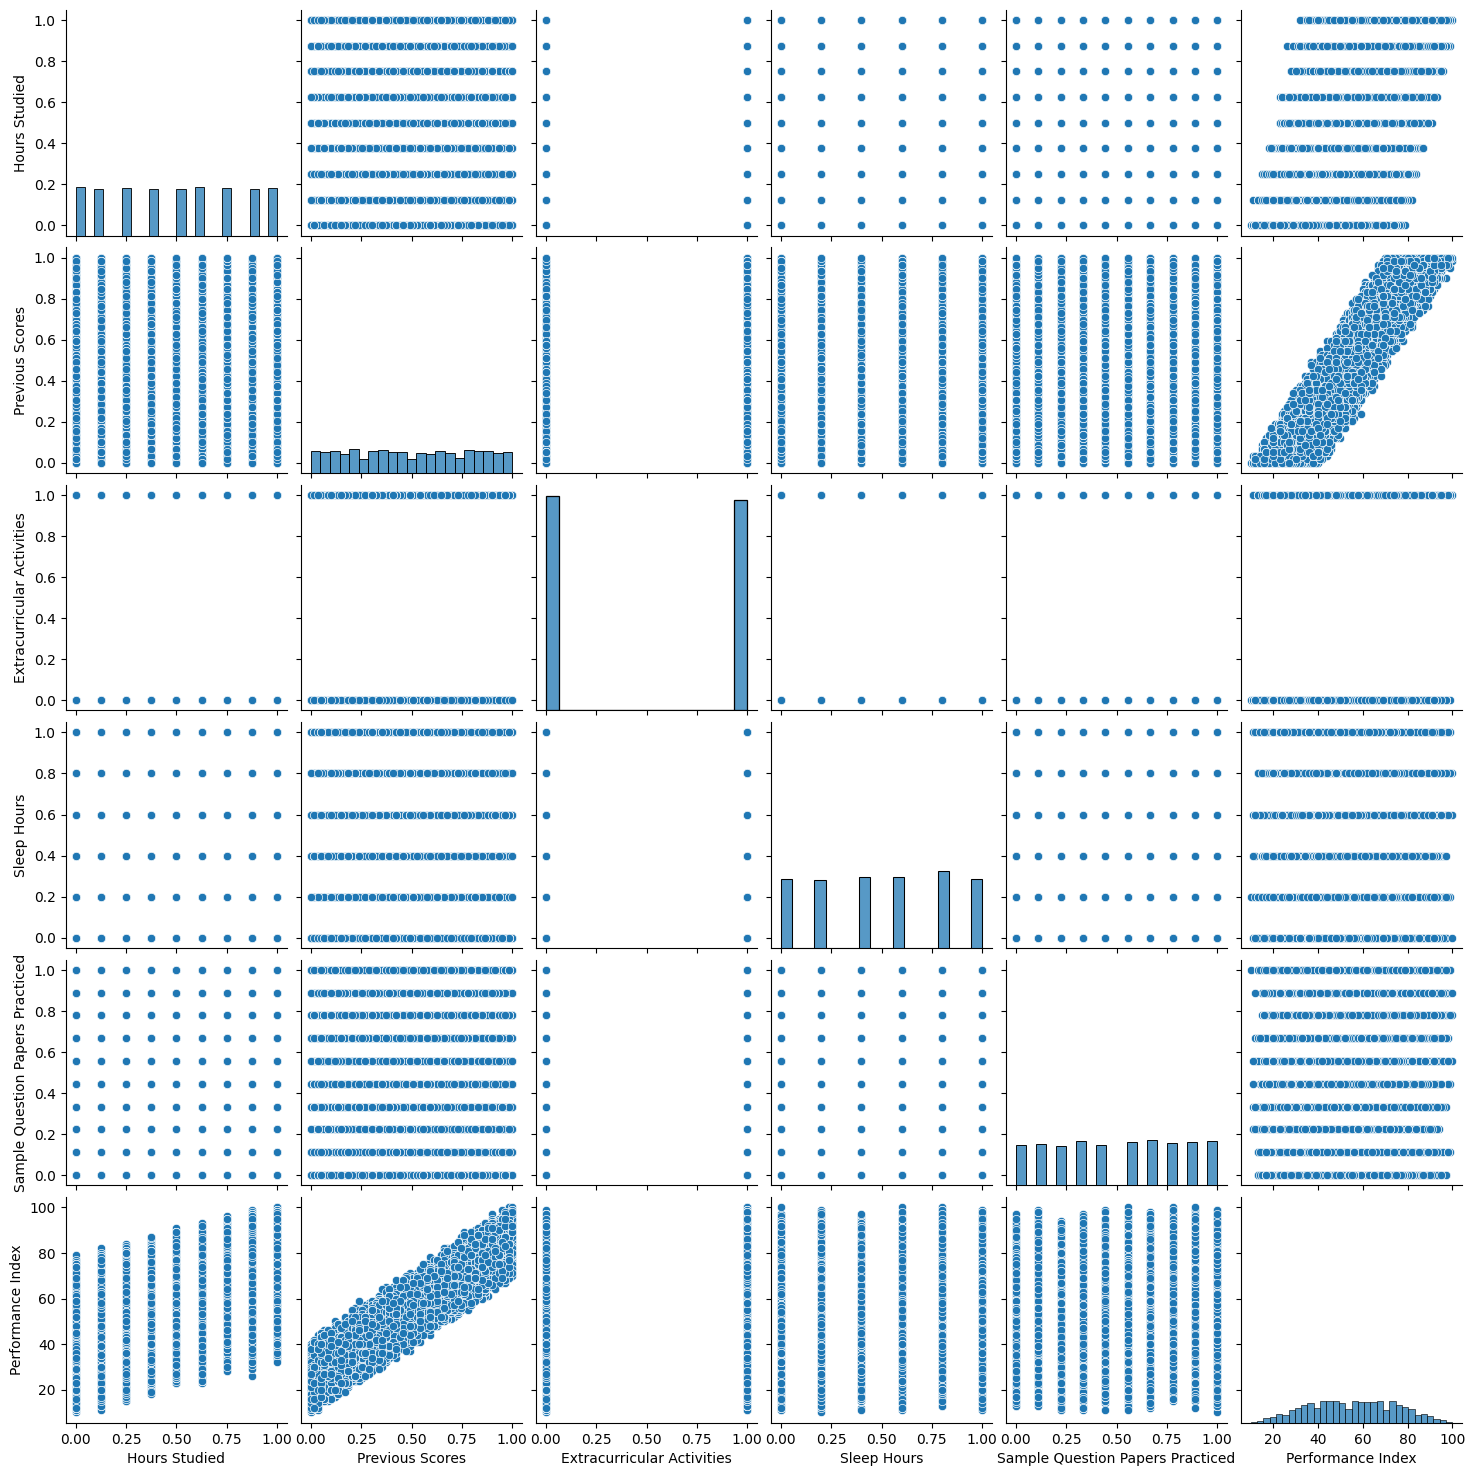

In [69]:
sns.pairplot(df)
plt.show()

In [70]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,0.750,1.000000,1.0,1.0,0.111111,91.0
1,0.375,0.711864,0.0,0.0,0.222222,65.0
2,0.875,0.186441,1.0,0.6,0.222222,45.0
3,0.500,0.203390,1.0,0.2,0.222222,36.0
4,0.750,0.593220,0.0,0.8,0.555556,66.0
...,...,...,...,...,...,...
9995,0.000,0.152542,1.0,0.0,0.222222,23.0
9996,0.750,0.406780,1.0,0.8,0.555556,58.0
9997,0.625,0.728814,1.0,0.8,0.555556,74.0
9998,1.000,0.966102,1.0,0.6,0.000000,95.0


In [71]:
# USING PRINCIPLE COMPONENT ANALYSIS FOR REDUCING THE INDEIPENDENT VARIABLES 

from sklearn.decomposition import PCA

x = df[cols]
y = df['Performance Index']

pca_full = PCA(n_components = x.shape[1])
pca = pca_full.fit(x)

joblib.dump(pca, "student_perf_pipeline.pkl")

['student_perf_pipeline.pkl']

In [76]:
pca = pca.transform(x)

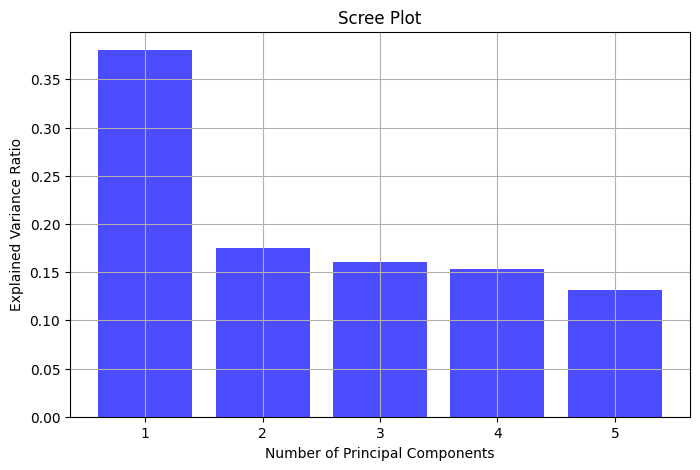

In [77]:
# Scree Plot (Explained Variance)
plt.figure(figsize=(8, 5))
plt.bar(range(1, x.shape[1] + 1), pca_full.explained_variance_ratio_, color='blue', alpha=0.7)
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.show()

In [80]:
class multiple_regression():
    def __init__(self,iterations = 10000, learning_rate = 0.1):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        
        self.bias = None

    def fit(self,x,y):
        n_samples,n_features = x.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.iterations):
            y_pred = self.predict(x)

            dw = np.dot(x.T, (y_pred - y)) / n_samples
            db = np.sum(y_pred - y)/n_samples

            self.weights -= self.lr*dw
            self.bias -= self.lr*db

    def predict(self,x):
        predictions = np.dot(x,self.weights)+self.bias
        return predictions
    
model = multiple_regression()
model.fit(pca,y)
print ("weights = ", model.weights)
print ("intercept = ", model.bias)

weights =  [ 1.11405182  4.26701452 18.97811168 -2.7198889  61.26684686]
intercept =  55.22479999999996
